# Week3 (Regression) 과제
## Boston Housing Data 분석
### 데이터 소개
- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 square feet.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built prior to 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property tax rate per $10,000.
- **PTRATIO**: Pupil-teacher ratio by town.
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
- **LSTAT**: Percentage of lower status of the population.

Target Variable:
- **MEDV**: Median value of owner-occupied homes in $1000s.

In [1]:
# 코랩 환경: 구글 드라이브를 코랩에 연동
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [5]:
# housing.xls가 포함된 경로를 저장해봅시다.
PATH = '/content/drive/MyDrive/[] KUBIG/'

In [6]:
# 본인 구글 드라이브에 업로드한 housing.xls 파일의 주소를 넣어주세요!
house = pd.read_excel(PATH+'housing.xls')

# Q1: `head`, `info`, `describe`, `shape` 함수를 실행해봅시다.

과제2 참고

In [7]:
display(house.head())
house.info()
display(house.describe())
print(house.shape)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


(506, 14)


# Q2: 각 변수의 결측치 (NaN 또는 Null)의 개수를 구해봅시다.

과제2 참고

In [8]:
house.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


# Q3: 각 변수별로 히스토그램을 그리고, Scatterplot Matrix를 그려봅시다

과제2 참고

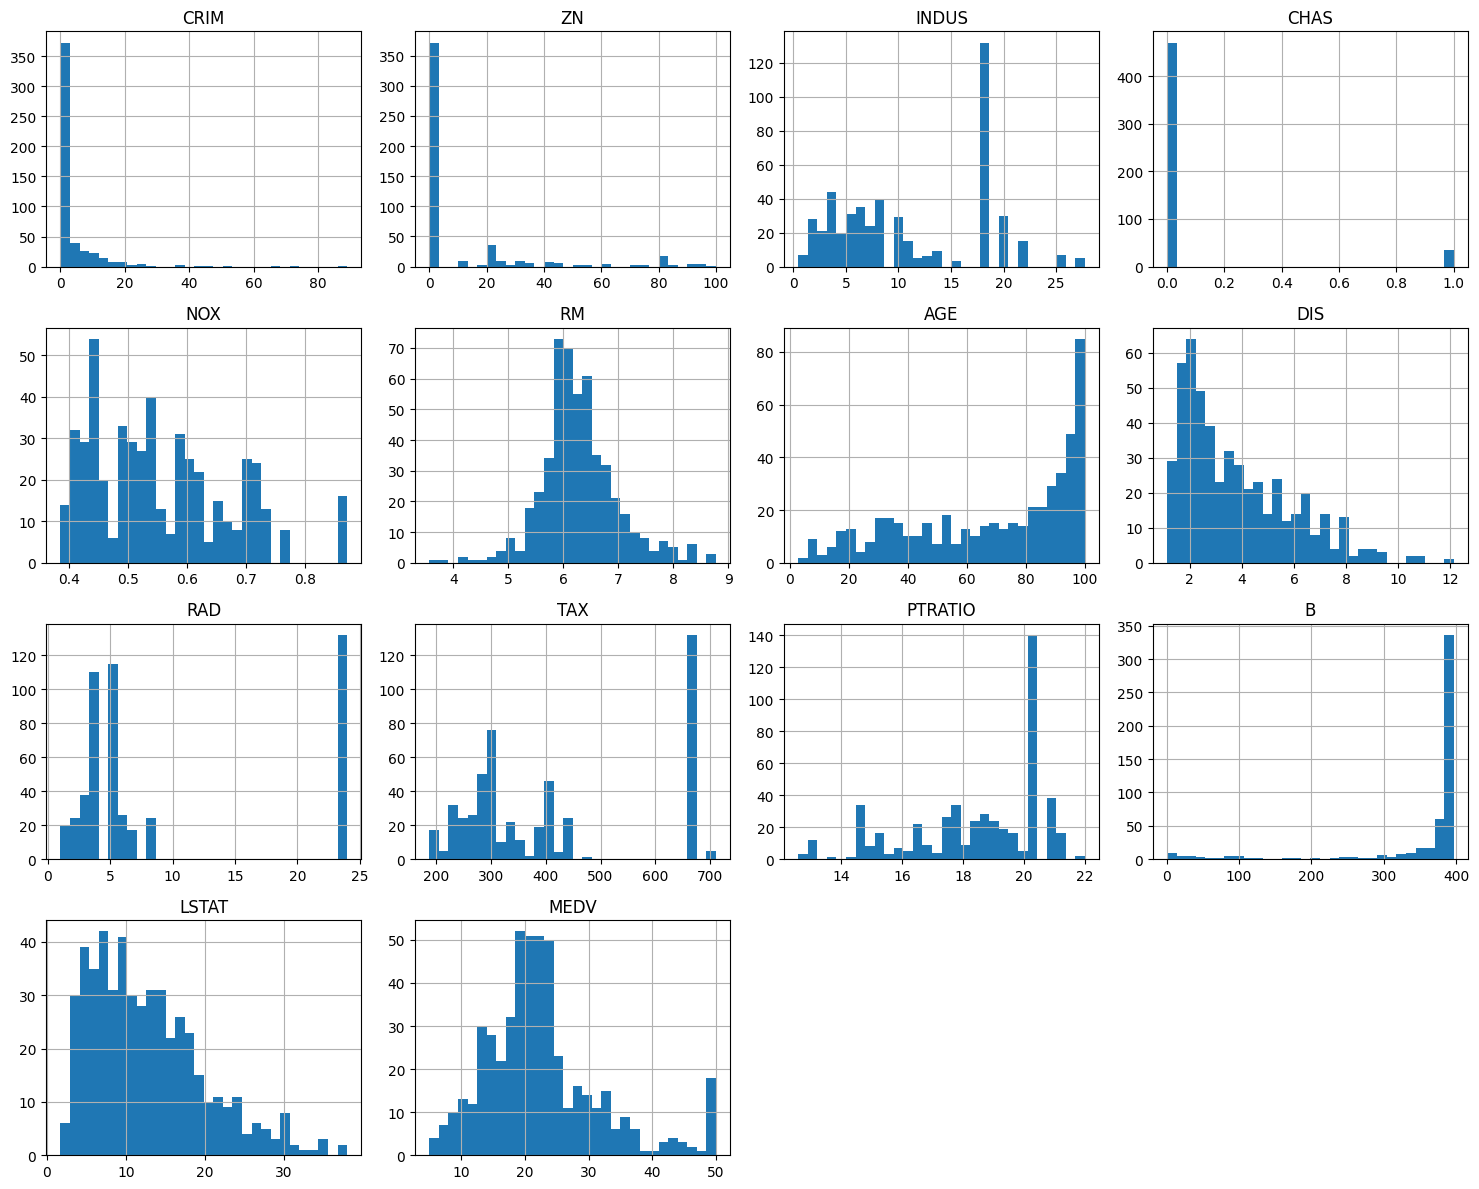

In [9]:
house.hist(bins=30, figsize=(15, 12))
plt.tight_layout()
plt.show()

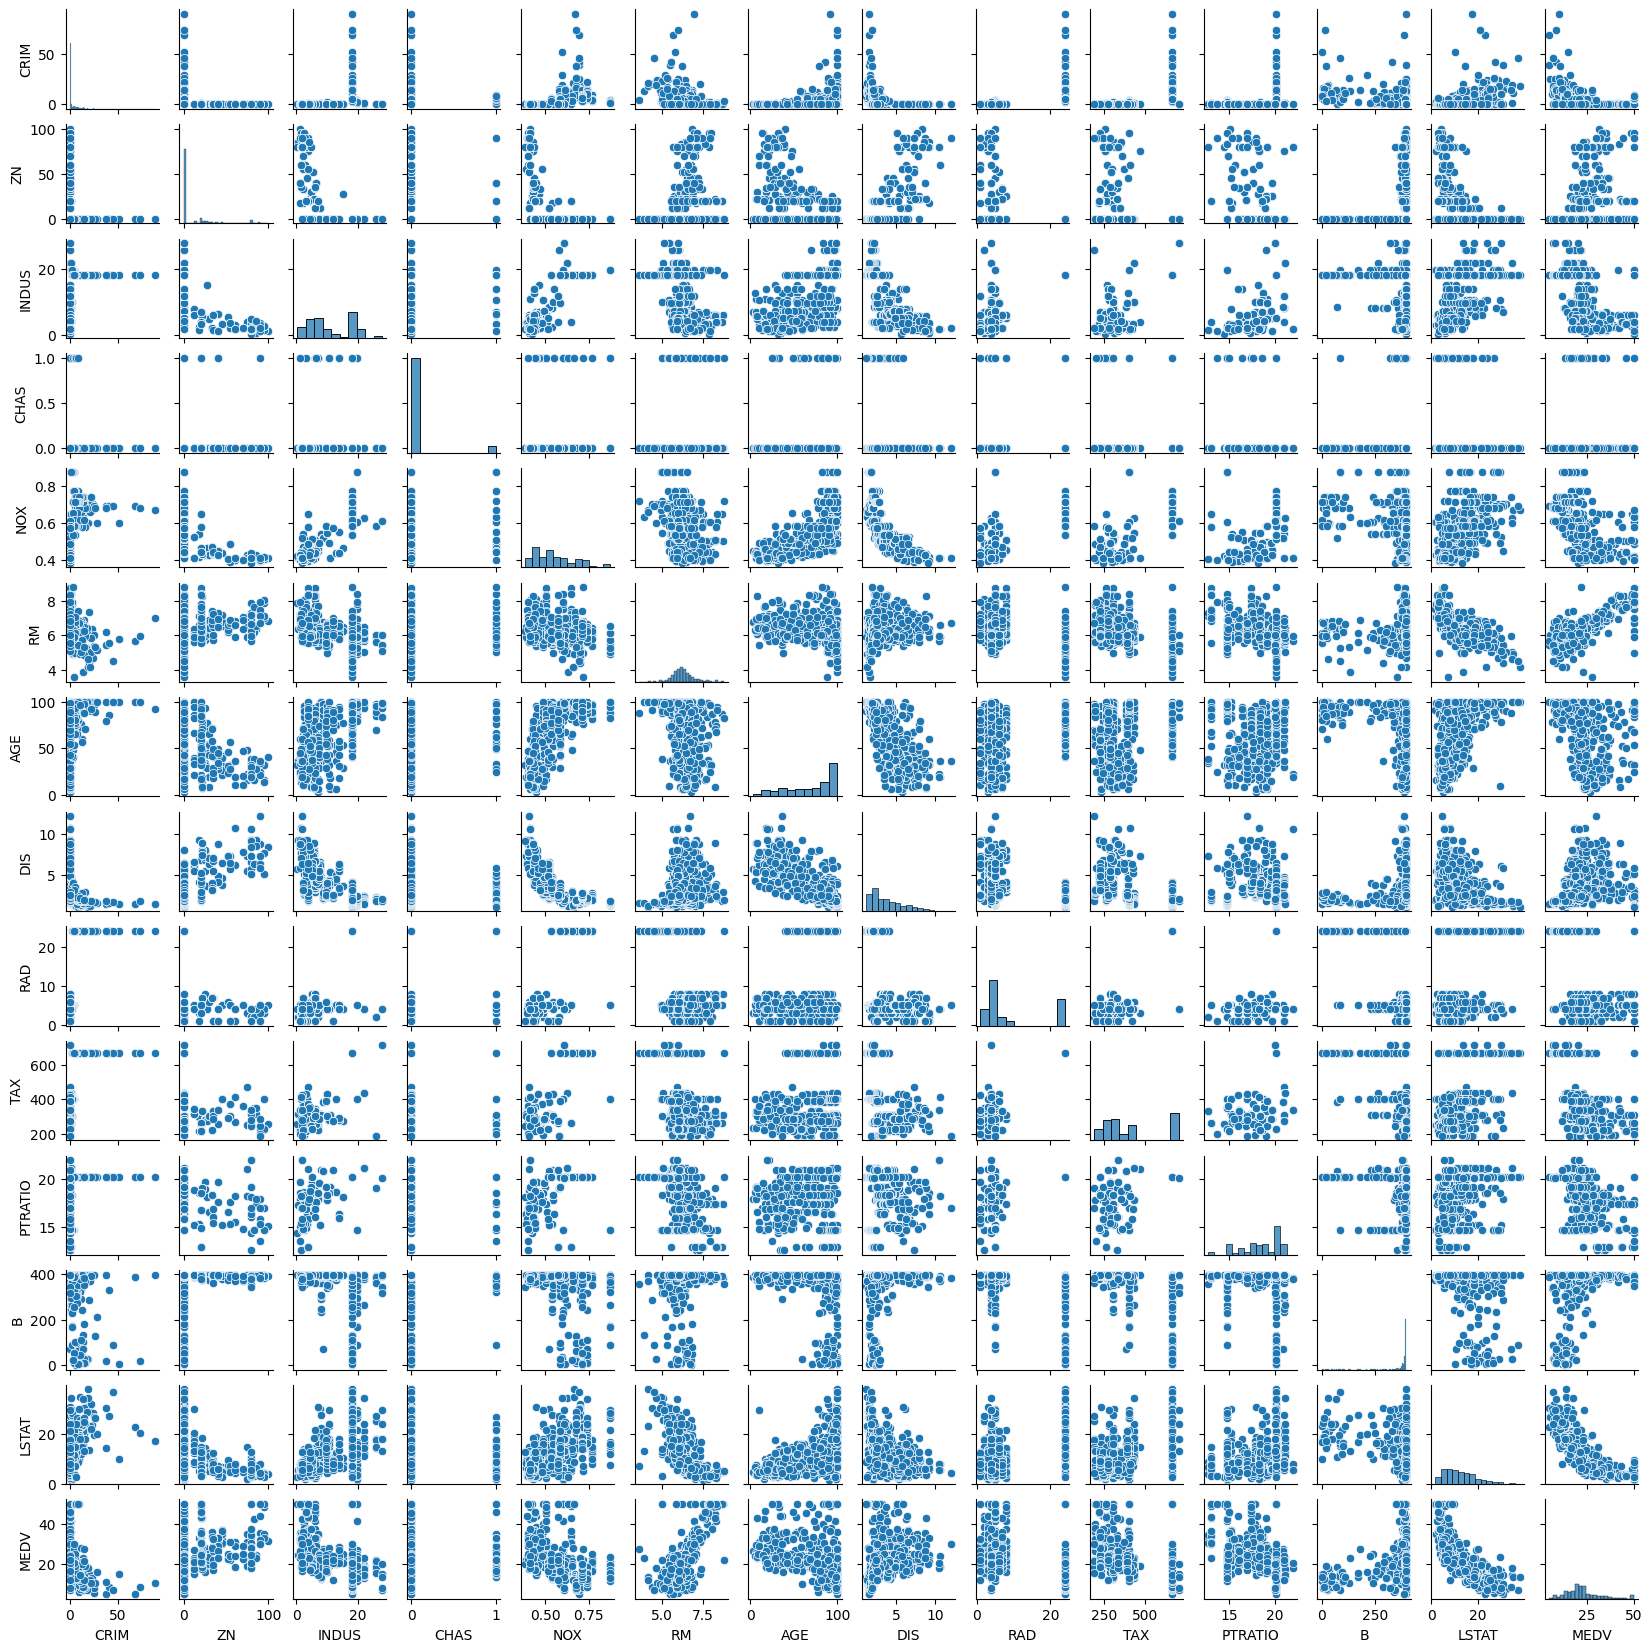

In [10]:
sns.pairplot(house, height=1.2)
plt.show()

## Q3-1. 다중공선성(multicolinearity)을 확인하기 위해 VIF를 추가로 확인해봅시다.

In [11]:
# 그대로 실행하기 !!
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(house.values, i) for i in range(house.shape[1])]
vif['features'] = house.columns
vif

,VIF Factor,features
0,2.131404,CRIM
1,2.910004,ZN
2,14.485874,INDUS
3,1.176266,CHAS
4,74.004269,NOX
5,136.101743,RM
6,21.398863,AGE
7,15.430455,DIS
8,15.369980,RAD
9,61.939713,TAX


## Q3-2.
VIF가 높은 변수가 하나씩 줄어들면 다른 변수들의 VIF에도 영향을 미치기 때문에 변수들을 한 번에 다 제거하기보다는 하나씩 제거하면서 확인해 나아가는 것이 바람직합니다! 여러 차례 VIF를 확인해보면서 변수를 제거해보세요!

In [12]:
vif = pd.DataFrame()
x_data = house.drop( 'RM' ,axis=1) # VIF 높은 변수 기입
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif

,VIF Factor,features
0,2.110287,CRIM
1,2.889159,ZN
2,14.202832,INDUS
3,1.174535,CHAS
4,62.073615,NOX
5,20.752654,AGE
6,14.258330,DIS
7,15.134503,RAD
8,61.603579,TAX
9,69.068505,PTRATIO


In [13]:
for col in ['PTRATIO', 'NOX', 'TAX']:
    x_data = x_data.drop(col, axis=1)
    vif = pd.DataFrame()
    vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
    vif["features"] = x_data.columns
    print(f'drop {col}')
    display(vif.sort_values('VIF Factor', ascending=False))

drop PTRATIO


,VIF Factor,features
4,59.247225,NOX
8,58.759509,TAX
5,20.427509,AGE
9,19.222365,B
7,15.130157,RAD
2,14.147928,INDUS
11,13.431156,MEDV
10,12.012673,LSTAT
6,9.639018,DIS
1,2.558330,ZN


drop NOX


,VIF Factor,features
7,54.753156,TAX
8,18.593595,B
4,17.056895,AGE
6,15.049247,RAD
2,13.152242,INDUS
10,11.446226,MEDV
9,11.031436,LSTAT
5,9.446150,DIS
1,2.548017,ZN
0,2.103346,CRIM


drop TAX


,VIF Factor,features
7,18.131319,B
4,16.449470,AGE
9,11.385287,MEDV
8,10.934458,LSTAT
2,9.024818,INDUS
5,8.722321,DIS
6,4.858231,RAD
1,2.465535,ZN
0,2.103261,CRIM
3,1.142745,CHAS


**house 데이터셋에 변수 제거를 적용하지 않고 우선 진행하세요! 추후에 MSE 비교를 통해 변수 제거를 확실히 해봅시다.**

# Q4: 데이터를 `X_train`, `X_test`, `y_train`, `y_test` 로 split해 봅시다

split 비율은 자유롭게 정해보시기 바랍니다.

In [14]:
X = house.drop('MEDV', axis=1)
y = house['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 13) (102, 13) (404,) (102,)


# Q5: `StandardScaler`로 표준화를 해봅시다

CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT 변수들만 `StandardScaler`을 해봅시다. (이들 중 다중공선성으로 인해 제거한 변수들이 있다면 제외하고 진행해주세요.)

`X_train`은 `fit_transform`, `X_test`는 `transform`을 이용하는 것에 유의합시다!

In [15]:
scale_cols = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.287702,-0.500320,1.033237,0,0.489252,-1.428069,1.028015,-0.802173,24,1.578434,0.845343,-0.074337,1.753505
15,-0.336384,-0.500320,-0.413160,0,-0.157233,-0.680087,-0.431199,0.324349,4,-0.584648,1.204741,0.430184,-0.561474
332,-0.403253,1.013271,-0.715218,0,-1.008723,-0.402063,-1.618599,1.330697,1,-0.602724,-0.637176,0.065297,-0.651595
423,0.388230,-0.500320,1.033237,0,0.489252,-0.300450,0.591681,-0.839240,24,1.578434,0.845343,-3.868193,1.525387
19,-0.325282,-0.500320,-0.413160,0,-0.157233,-0.831094,0.033747,-0.005494,4,-0.584648,1.204741,0.379119,-0.165787


# Q6: 5-fold Cross-Validation으로 `LinearRegression`을 적합해봅시다.

각 fold마다 적합 후 MSE, MAE, RMSE, $R^2$를 구하고, coefficient과 intercept를 `print` 해보세요.

In [16]:
from sklearn.model_selection import KFold

def run_cv(X_tr, y_tr, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = {'MSE': [], 'MAE': [], 'RMSE': [], 'R2': []}
    for i, (tr_idx, val_idx) in enumerate(kf.split(X_tr), 1):
        model = LinearRegression()
        model.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
        pred = model.predict(X_tr.iloc[val_idx])
        y_val = y_tr.iloc[val_idx]
        mse = metrics.mean_squared_error(y_val, pred)
        mae = metrics.mean_absolute_error(y_val, pred)
        rmse = np.sqrt(mse)
        r2 = metrics.r2_score(y_val, pred)
        scores['MSE'].append(mse); scores['MAE'].append(mae)
        scores['RMSE'].append(rmse); scores['R2'].append(r2)
        print(f'[Fold {i}] MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}')
        print('  coefficient:', dict(zip(X_tr.columns, np.round(model.coef_, 4))))
        print(f'  intercept: {model.intercept_:.4f}')
    print('\n[Mean]', {k: round(np.mean(v), 4) for k, v in scores.items()})
    return {k: np.mean(v) for k, v in scores.items()}

base_score = run_cv(X_train, y_train)

[Fold 1] MSE: 23.2864 | MAE: 3.2108 | RMSE: 4.8256 | R2: 0.6725
  coefficient: {'CRIM': np.float64(-0.9481), 'ZN': np.float64(0.7586), 'INDUS': np.float64(0.3009), 'CHAS': np.float64(3.0076), 'NOX': np.float64(-2.2275), 'RM': np.float64(3.5129), 'AGE': np.float64(-0.0702), 'DIS': np.float64(-3.2193), 'RAD': np.float64(0.2202), 'TAX': np.float64(-1.4567), 'PTRATIO': np.float64(-2.0815), 'B': np.float64(1.1573), 'LSTAT': np.float64(-3.2812)}
  intercept: 20.5048
[Fold 2] MSE: 23.5646 | MAE: 3.4965 | RMSE: 4.8543 | R2: 0.7601
  coefficient: {'CRIM': np.float64(-1.0581), 'ZN': np.float64(0.7422), 'INDUS': np.float64(0.1049), 'CHAS': np.float64(3.093), 'NOX': np.float64(-2.0143), 'RM': np.float64(2.7999), 'AGE': np.float64(-0.1748), 'DIS': np.float64(-3.3261), 'RAD': np.float64(0.243), 'TAX': np.float64(-1.7421), 'PTRATIO': np.float64(-1.7766), 'B': np.float64(1.0934), 'LSTAT': np.float64(-3.9721)}
  intercept: 20.1013
[Fold 3] MSE: 36.4745 | MAE: 3.7736 | RMSE: 6.0394 | R2: 0.5895
  coeffi

### Q6-1: 다중공선성이 높았던 변수를 제거한 후 다시 train_test_split, scaler, 5-fold CV 과정으로 `LinearRegression`을 적합한 후 Q6에서 구한 평균 MSE(or MAE, RMSE, $R^2$)와 비교해보세요.

In [17]:
# 다중공선성을 불러일으키는 변수 제거
house_new = house.drop(['RM', 'PTRATIO', 'NOX', 'TAX'], axis=1) # VIF 높은 변수들 기입

In [18]:
X_new = house_new.drop('MEDV', axis=1)
y_new = house_new['MEDV']
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

scale_cols_new = [c for c in scale_cols if c in X_new.columns]
scaler_new = StandardScaler()
X_train_new = X_train_new.copy()
X_test_new = X_test_new.copy()
X_train_new[scale_cols_new] = scaler_new.fit_transform(X_train_new[scale_cols_new])
X_test_new[scale_cols_new] = scaler_new.transform(X_test_new[scale_cols_new])

new_score = run_cv(X_train_new, y_train_new)

print('\n', pd.DataFrame({'전체 변수': base_score, '변수 제거 후': new_score}).round(4))

[Fold 1] MSE: 25.3734 | MAE: 3.7915 | RMSE: 5.0372 | R2: 0.6431
  coefficient: {'CRIM': np.float64(-0.9922), 'ZN': np.float64(2.0164), 'INDUS': np.float64(-1.9755), 'CHAS': np.float64(3.885), 'AGE': np.float64(0.6715), 'DIS': np.float64(-3.9195), 'RAD': np.float64(0.0029), 'B': np.float64(0.8359), 'LSTAT': np.float64(-6.4041)}
  intercept: 22.4785
[Fold 2] MSE: 41.3104 | MAE: 4.4516 | RMSE: 6.4273 | R2: 0.5794
  coefficient: {'CRIM': np.float64(-0.9396), 'ZN': np.float64(1.7791), 'INDUS': np.float64(-1.8188), 'CHAS': np.float64(4.2482), 'AGE': np.float64(0.2687), 'DIS': np.float64(-3.4685), 'RAD': np.float64(-0.0052), 'B': np.float64(0.8776), 'LSTAT': np.float64(-6.1992)}
  intercept: 22.3767
[Fold 3] MSE: 38.3394 | MAE: 4.4901 | RMSE: 6.1919 | R2: 0.5685
  coefficient: {'CRIM': np.float64(-0.9109), 'ZN': np.float64(1.8629), 'INDUS': np.float64(-1.596), 'CHAS': np.float64(2.7907), 'AGE': np.float64(0.0155), 'DIS': np.float64(-3.8317), 'RAD': np.float64(-0.0271), 'B': np.float64(0.6998)

# Q7(Optional): `GridSearchCV`를 이용하여 `Lasso`를 적합해봅시다.

찾아야 하는 최적 파라미터는

- `alpha`: 0.01, 0.1, 1, 10 중에서 찾기
- `fit_intercept`: `True`, `False`에서 찾기

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

위 링크를 참조하여 `GridSearCV`의 `scoring`을 3가지 이상 사용해보세요

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

param_grid = {'alpha': [0.01, 0.1, 1, 10], 'fit_intercept': [True, False]}
scoring = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']

grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring=scoring, refit='neg_mean_squared_error')
grid.fit(X_train, y_train)

print('best params:', grid.best_params_)
print('best MSE:', -grid.best_score_)
print('test MSE:', metrics.mean_squared_error(y_test, grid.predict(X_test)))

cols = ['params', 'mean_test_neg_mean_squared_error', 'mean_test_neg_mean_absolute_error', 'mean_test_r2']
display(pd.DataFrame(grid.cv_results_)[cols].sort_values('mean_test_neg_mean_squared_error', ascending=False))

best params: {'alpha': 0.01, 'fit_intercept': True}
best MSE: 23.66799421099412
test MSE: 24.2854402897632


,params,mean_test_neg_mean_squared_error,mean_test_neg_mean_absolute_error,mean_test_r2
0,"{'alpha': 0.01, 'fit_intercept': True}",-23.667994,-3.439845,0.724274
2,"{'alpha': 0.1, 'fit_intercept': True}",-24.044975,-3.394753,0.719896
4,"{'alpha': 1, 'fit_intercept': True}",-30.407262,-3.842461,0.645711
1,"{'alpha': 0.01, 'fit_intercept': False}",-66.407087,-6.297761,0.217235
3,"{'alpha': 0.1, 'fit_intercept': False}",-66.592090,-6.282828,0.214618
6,"{'alpha': 10, 'fit_intercept': True}",-75.821212,-6.416684,0.120806
5,"{'alpha': 1, 'fit_intercept': False}",-76.003428,-6.471661,0.106621
7,"{'alpha': 10, 'fit_intercept': False}",-300.766806,-15.232127,-2.492487


# Q8(Optional): `RandomizedSearchCV`를 이용하여 `Ridge`를 적합해 봅시다.

CV를 이용한 hyperparameter tuning의 또다른 방법은 `RandomizedSearchCV`입니다.
Tuning해야 하는 모수가 많을 경우 이 방법이 빠르다는 장점이 있습니다.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#

위 링크를 참조하거나 구글링을 하여 `Ridge`를 적합해보세요.

`n_iter`와, 파라미터 공간을 자유롭게 조정해보세요.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import loguniform

param_dist = {'alpha': loguniform(1e-3, 1e3), 'fit_intercept': [True, False], 'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'saga']}

rs = RandomizedSearchCV(Ridge(), param_dist, n_iter=50, cv=5, scoring='neg_mean_squared_error', random_state=42)
rs.fit(X_train, y_train)

print('best params:', rs.best_params_)
print('best MSE:', -rs.best_score_)
print('test MSE:', metrics.mean_squared_error(y_test, rs.predict(X_test)))

best params: {'alpha': np.float64(4.387382373522994), 'fit_intercept': True, 'solver': 'auto'}
best MSE: 23.609028498158086
test MSE: 24.275879517411234
